<a href="https://colab.research.google.com/github/MihaiCiorascu/AI-Self-Study/blob/main/MDL_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install git+https://github.com/DMJTax/prtools.git

  Cloning https://github.com/DMJTax/prtools.git to /tmp/pip-req-build-tmrp0u4p
  Running command git clone --filter=blob:none --quiet https://github.com/DMJTax/prtools.git /tmp/pip-req-build-tmrp0u4p
  Resolved https://github.com/DMJTax/prtools.git to commit 5e355ed8c0f4d16eed0b6324eb720d4d6c0a7e13
  Preparing metadata (setup.py) ... done


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import prtools as pr

In [3]:
# Use the following code to create a dummy dataset containing 10 objects with 2 features each.

x = np.array(
    [[1, 5], [4, 5], [7, 8],
    [10, 11], [11, 14], [16, 17],
    [19, 20], [22, 2], [25, 23],
    [28, 20]]
    )

In [4]:
# If axis = 0, the mean/std is computed for each feature across all objects

mean = np.mean(x, axis=0)
std = np.std(x, axis=0)

print('Mean:', mean)
print('Std:', std)
print()

# If axis = 1, the mean/std is computed for each object across all features

mean = np.mean(x, axis=1)
std = np.std(x, axis=1)

print('Mean:', mean)
print('Std:', std)
print()

# If the param is not specified, the mean/std is computed for all the elements in the array

mean = np.mean(x)
std = np.std(x)

print('Mean:', mean)
print('Std:', std)
print()

Mean: [14.3 12.5]
Std: [8.67236992 7.00357052]

Mean: [ 3.   4.5  7.5 10.5 12.5 16.5 19.5 12.  24.  24. ]
Std: [ 2.   0.5  0.5  0.5  1.5  0.5  0.5 10.   1.   4. ]

Mean: 13.4
Std: 7.933473388119481



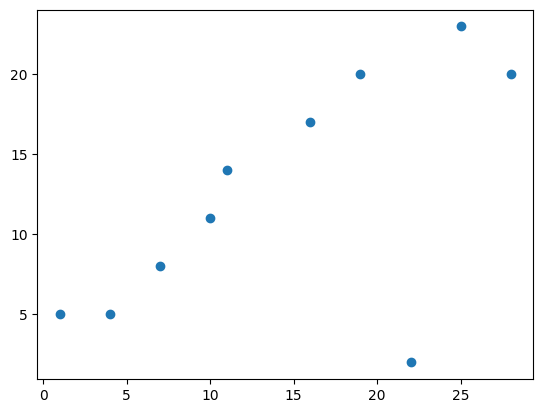

In [5]:
# When a datasset contains just 2 features per object, it can be visualized in a scatterplot

plt.scatter(x[:, 0], x[:, 1])

In [6]:
#You can create labels for the prev generated data by defining another numpy array

lab = np.array([1,1,1,1,2,2,2,2,2,2]).reshape(10,1)
#lab = np.array([1,1,1,1,2,2,2,2,2,2]).T # alternative

#Then, you can create a PRTools dataset using the prdataset function

a = pr.prdataset(x, lab)
print(a)

10 by 2 prdataset with 2 classes: [4 6]


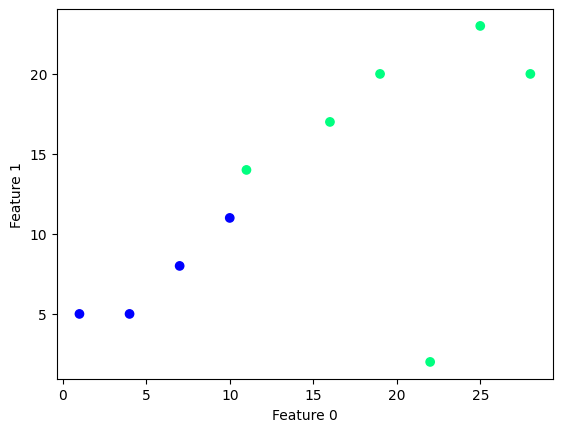

In [7]:
#If visualized, it will show the labes in diff colors

pr.scatterd(a)

Banana dataset 100 by 2 prdataset with 2 classes: [50 50]


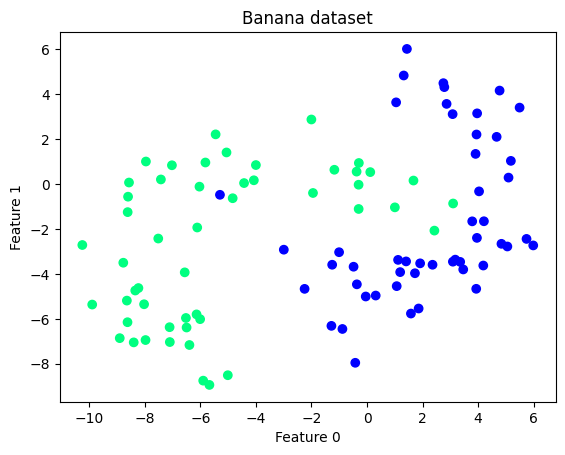

In [8]:
#There is a set of predefined datasets in PRTools that can be loaded using
#functions as gendatb, gendatc, gendats ...

#For instance, to load a Banana shaped dataset, you can use the following line

b = pr.gendatb()
print(b)

#... and then visualize it
pr.scatterd(b)

#Other datasets that can be loaded in the same way:

# - gendatc: generation of circular classes
# - gendats: generation of two Gaussian classes
# - gendatd: generation of two difficult classes
# - gendath: generation of the hygleyman dataset
# ... and more!

Nearest mean, 2 to 2 trained mapping
Banana dataset 100 by 2 prdataset with 2 classes: [50 50]
0.15


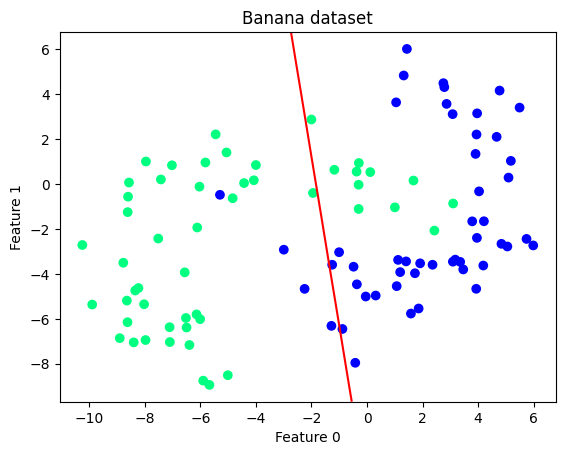

In [9]:
#Assume we want to train a nearest mean classifier on the defined Banana dataset.
#In PRTools u do:

w = pr.nmc()
w.train(b)
print(w) #this will show the classifier params

c = w.eval(b)
print(c)

e = pr.testc(c)
print(e) #this will show the classification error

#to visualise the decision boundary of the classifier, you can use the following code

pr.scatterd(b)
pr.plotc(w)

Support vector classifier, 2 to 2 trained mapping
Banana dataset 100 by 2 prdataset with 2 classes: [50 50]
0.03


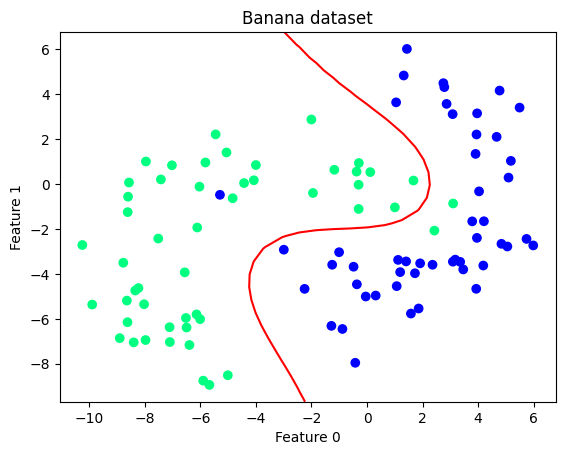

In [10]:
#Some classifiers require additional hyperparameters to be specified.
#For instance, in the support vector classifier, you can specify the kernel, a kernel parameter, and a regularisation parameter.
#Or in the k-nearest neighbor classifier you can specify the number of neighbors k.
#You can supply that as additional input during training. For example, for svc:

w = pr.svc(('rbf', 4.5, 1))
w.train(b)
print(w)

c = w.eval(b)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(b)
pr.plotc(w)

3-NN+Bayes rule, 2 to 2 trained mapping
Banana dataset 100 by 2 prdataset with 2 classes: [50 50]
0.02


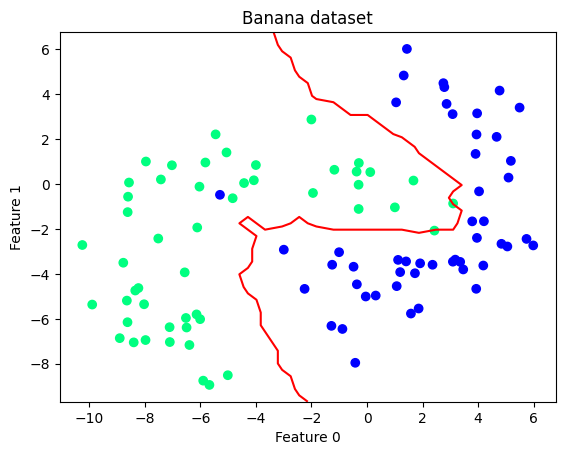

In [11]:
#... or for knnc:

w = pr.knnc(3)
w.train(b)
print(w)

c = w.eval(b)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(b)
pr.plotc(w)

## 2 - Creating Maps and Decision Boundaries (**Coding**)

So far, we have visualized the decision boundary and computed the classification error on the training set. However, the classification error on the training set is not a good indicator of the performance of the classifier. Here is a complete example of training a svc classifier and visualizing the decision boundary and classification error on a test set.


Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
0.025


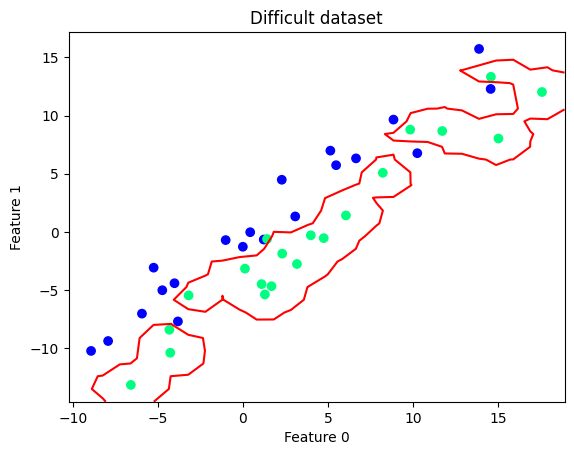

In [12]:
#Create hard training dataset gendatd

d = pr.gendatd()
print(d)

#Train a ldc classifier on the dataset

w = pr.svc()
w.train(d)

#Evaluate the classifier on the training set

c = w.eval(d)
print(c)

e = pr.testc(c)
print(e)

#Visualize the training set

pr.scatterd(d)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
0.225


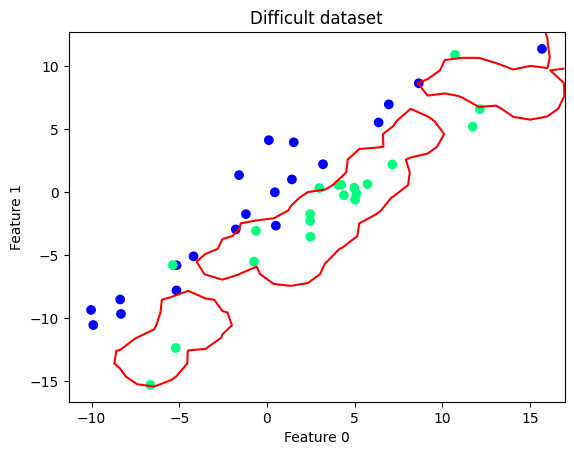

In [13]:
#Create a test dataset using gendatd

t = pr.gendatd()
print(t)

#Evaluate the classifier on the test set

c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

#Visualize the test set
pr.scatterd(t)
pr.plotc(w)

### **Exercise 2.1**

Train the following classifiers on some 2D datasets and visualize the decision boundaries. Also visualize the error on the test set.

**Classifiers:**
* ldc -> Linear discriminant analysis
* qdc -> Quadratic discriminant analysis
* nmc -> Nearest mean classifier
* fisherc -> Fishers linear discriminant
* knnc -> k-nearest neighbor classifier
* parzenc -> Parzen classifier
* naivebc -> Naive-Bayes classifier
* mogc -> Mixture-of-Gaussians classifier
* stumpc -> Decision stump classifier
* dectreec -> Decision tree classifier
* adaboostc -> AdaBoost
* svc -> Support vector classifier

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [57 43]
LDA, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [57 43]
0.2


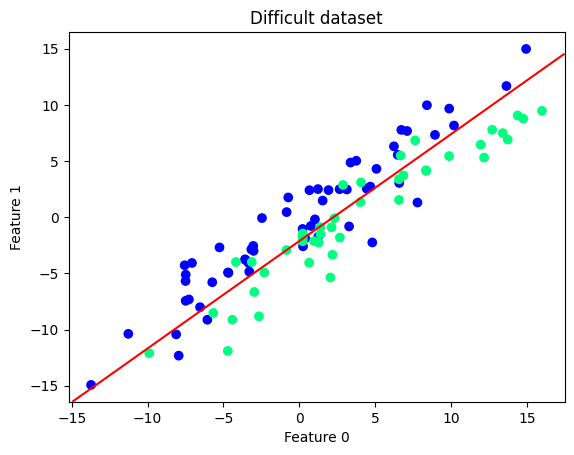

In [14]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.ldc()
w.train(a)
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [47 53]
QDA, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [47 53]
0.21


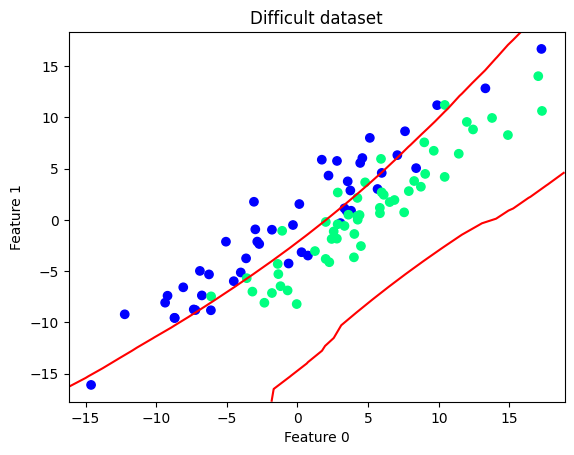

In [15]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.qdc()
w.train(a)
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [44 56]
Nearest mean, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [44 56]
0.47


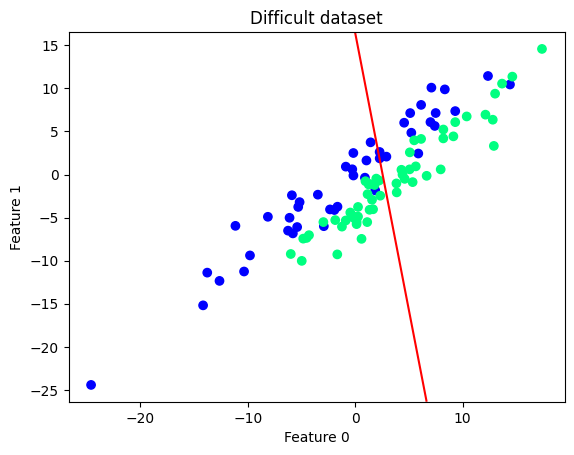

In [16]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.nmc()
w.train(a)
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [47 53]
Fisher, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [47 53]
0.21


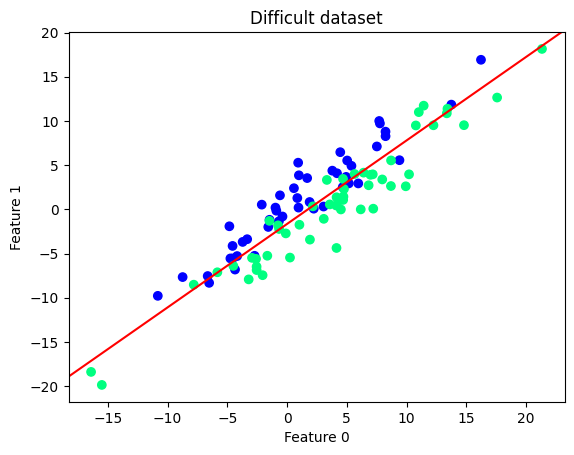

In [17]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.fisherc()
w.train(a)
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [53 47]
5-NN+Bayes rule, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [53 47]
0.25


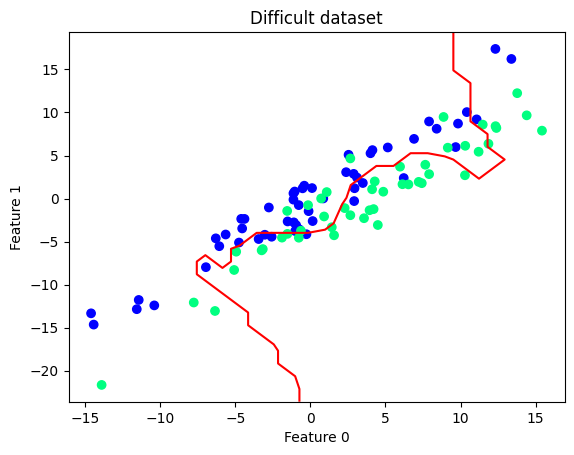

In [18]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.knnc(a, 5)
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [58 42]
Parzen density+Bayes rule, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [58 42]
0.26


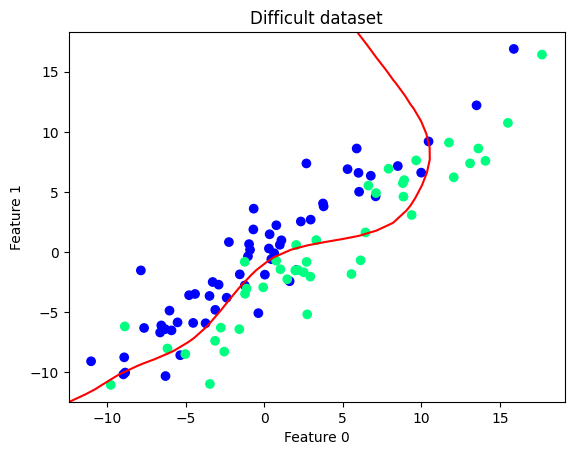

In [19]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.parzenc(a, 3)
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [39 61]
Naive Bayes density+Bayes rule, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [39 61]
0.33


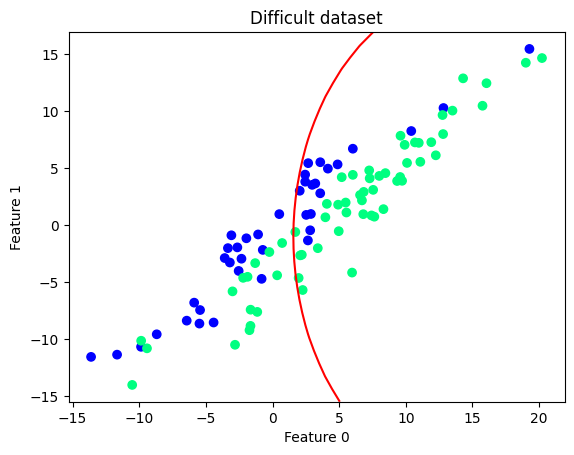

In [20]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.naivebc()
w.train(a)
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [52 48]
mogm+Bayes rule, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [52 48]
0.31


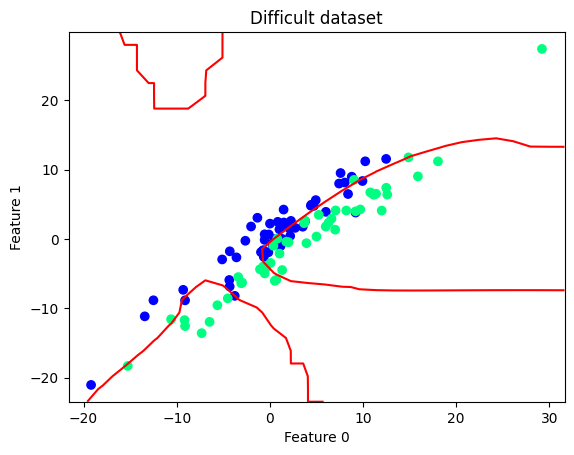

In [21]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.mogc()
w.train(a)
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [42 58]
Decision stump, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [42 58]
0.36


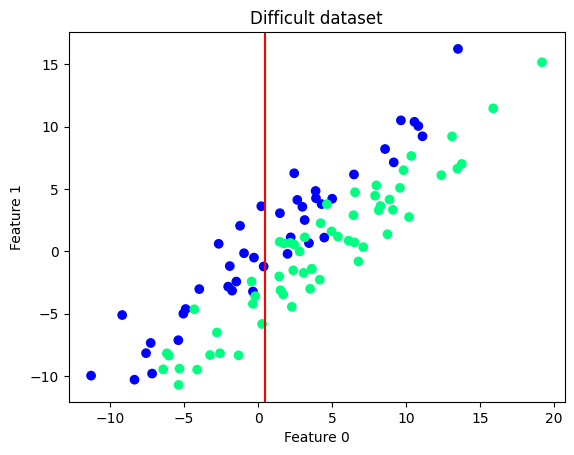

In [22]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.stumpc()
w.train(a)
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [52 48]
Decision tree, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [52 48]
0.36


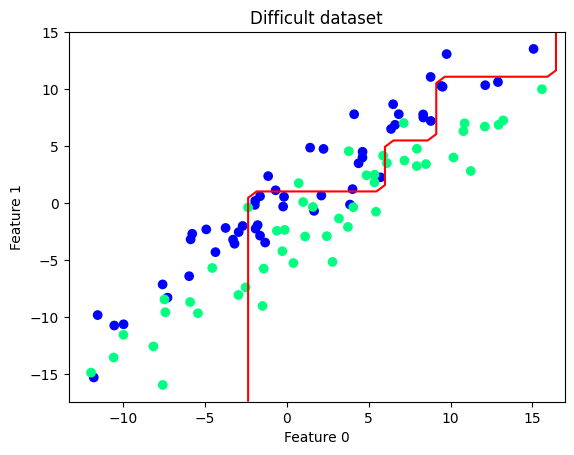

In [23]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.dectreec()
w.train(a)
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [57 43]
AdaBoost, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [57 43]
0.33


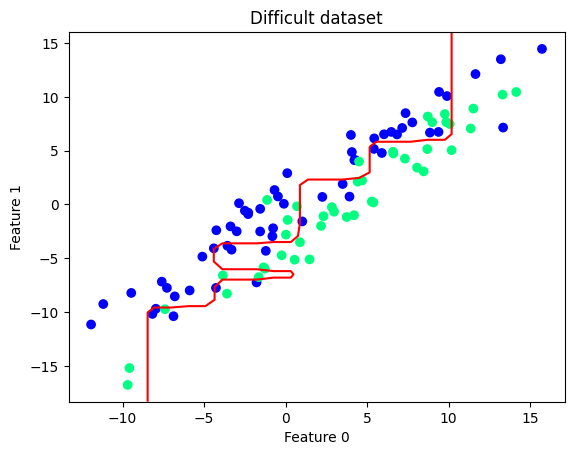

In [24]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.adaboostc()
w.train(a)
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

Difficult dataset 40 by 2 prdataset with 2 classes: [20 20]
Difficult dataset 100 by 2 prdataset with 2 classes: [50 50]
Support vector classifier, 2 to 2 trained mapping
Difficult dataset 100 by 2 prdataset with 2 classes: [50 50]
0.28


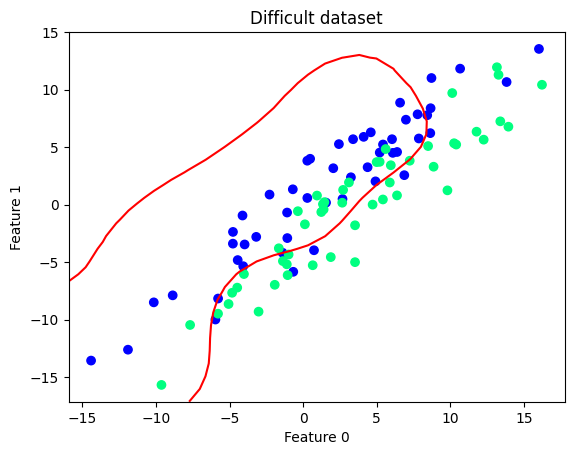

In [25]:
#Create train and test set
a = pr.gendatd()
print(a)
t = pr.gendatd(100)
print(t)

#Train
w = pr.svc(a, ('rbf', 4.5, 1))
print(w)

#Evaluate the classifier on the test set
c = w.eval(t)
print(c)

e = pr.testc(c)
print(e)

pr.scatterd(t)
pr.plotc(w)

## 3 - Classification with Normal Densities (**Coding**)

### **Exercise 3.1**

Consider two 2D normal distributions with different means but equal covariance matrices.


#### (a) Shape of the Optimal Decision Boundary

What shape does the optimal decision boundary have?

Generate 10 data points per class from a data set that fulfills the above assumptions. Create a data set with these 20 points and these two classes.

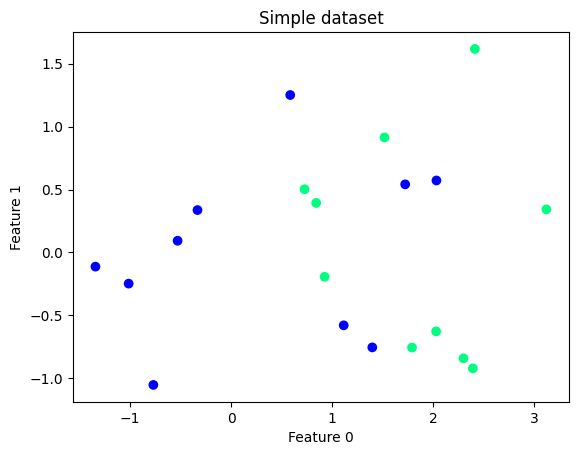

In [26]:
a = pr.gendats([10, 10])
pr.scatterd(a)

#### (b) Shape of the Quadratic Discriminant Boundary

Given the shape of the optimal decision boundary, how does the boundary look for the trained normal density-based quadratic discriminant?

We can estimate linear discriminants by means of `ldc(a)` and quadratic discriminant boundaries by means of `qdc(a)`.

The PRTools command `plotc` plots the decision boundary. If you plotted decision boundaries of multiple classifiers in one plot command `pr.plotc([w1, w2])`, you will get a legend.

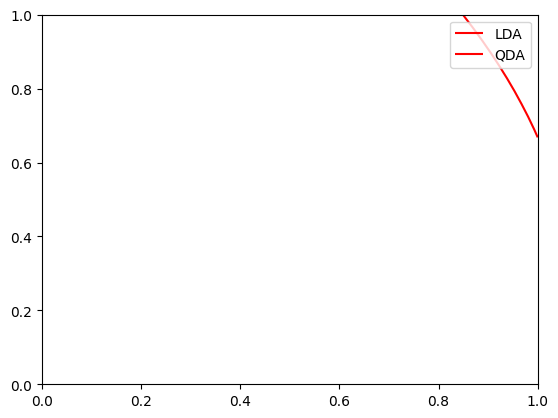

In [27]:
w1 = pr.ldc(a)
w2 = pr.qdc(a)

pr.plotc([w1, w2])

#### (c) Scatter Plot and Decision Boundaries

Scatter the data set and plot the decision boundary estimated by means of `ldc(a)` and `qdc(a)`. Can you explain their difference? You might want to revisit the previous question (b).

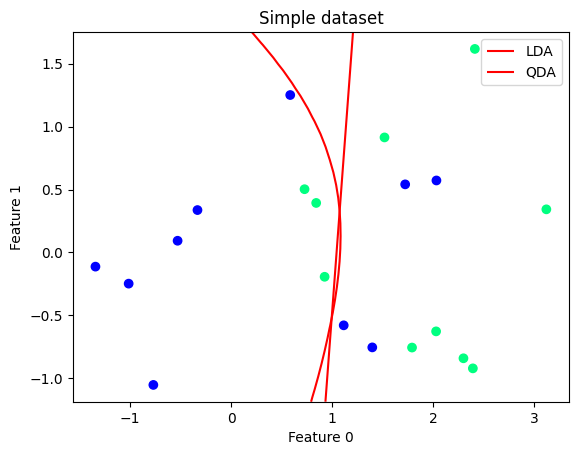

In [28]:
pr.scatterd(a)

pr.plotc([w1, w2])

### Answer
Ldc is by construction linear, qdc will typically remain nonlinear due to the finite sample size.

#### (d) Increasing Number of Data Points

What happens when the number of points per class increases? What happens in the limit of an infinite number of points?

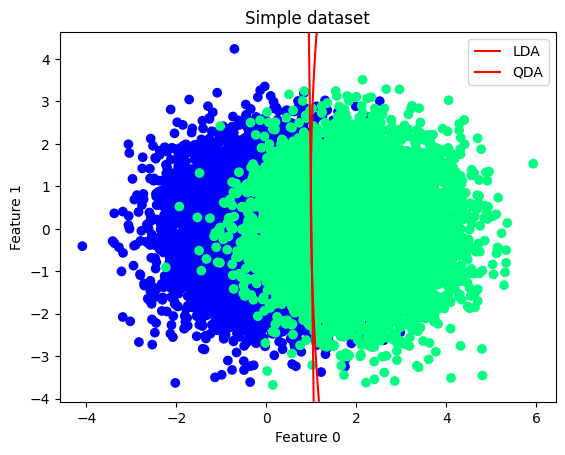

In [29]:
a = pr.gendats([10000, 10000])
pr.scatterd(a)

w1 = pr.ldc(a)
w2 = pr.qdc(a)

pr.plotc([w1, w2])

### Answer
When the number of points goes to infinity, the solutions by ldc and qdc will coincide.

---


## 4 - Density estimation using Parzen densities **(Coding)**

Next to classifiers, PRTools also has the possibility to estimate densities. In this section we are going to estimate the density using a Parzen density estimator, called parzenm in PRTools

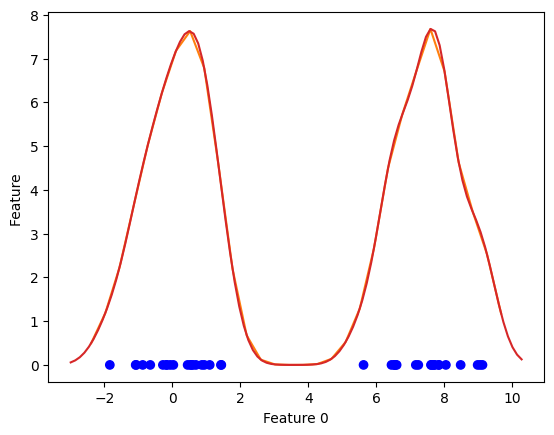

In [32]:
#We start with creating a simple dataset with:
a = pr.gendats([20, 20], 1, 8)

#We define the width param h for Parzen kernel:
h = 0.5

#The function parzenm estimates density for a given dataset.
#In most cases a PRTools prdataset is labeled, and these labels are used in the
#function parzenm to estimate a density for each class. To define a Parzen density
#estimator with a certain width parameter h on the entire dataset, ignoring labels,
#type:
a = pr.prdataset(+a)
w = pr.parzenm(a, h)

#This mapping can now be plotted along with the data:
pr.scatterd(a)
pr.plotm(w)

#If your graphs look like a little "bumpy", you can increase the grid size PRTools
#uses for plotting:

pr.plotm(w, gridsize=100)

When you want to evaluate the fit of a density model to some data, you have to define an error. One possibility is to use the log-likelihood, defined as:

$$
LL(X) = \log \prod_i \hat{p}(x_i) = \sum_i \log(\hat{p}(x_i)) \tag{1.2}
$$

The better the data $x$ fits in the probability density model $\hat{p}$, the higher the values of $\hat{p}(x)$ will be. This will result in a high value of $\sum_i \log(\hat{p}(x_i))$. When we have different probability density estimates $\hat{p}$, we use the one which has the highest value of $LL$.

Note that when we fill in different values for the width parameters $h$ in the Parzen density estimation, we have different estimates $\hat{p}$. Using the log-likelihood as a criterion, we can optimize the value of this free parameter $h$ to maximize $LL$.

To get an honest estimate of the log-likelihood, we have to evaluate the log-likelihood (1.2) on a test set. That means that we have to make (or measure) new data from the same distribution as where the training data came from. When we evaluate the log-likelihood on the data on which the probability density was fitted, we would get a too optimistic estimation of the error. We might conclude that we have fitted the data very well, while actually a new dataset from the same distribution does not fit in the density at all! Therefore, if you want to evaluate the performance of an estimated $\hat{p}$, use an independent test set!


### **Exercise 4.1**

Use the data from the same distribution as in the previous exercise to train a Parzen density estimator for different values of h. Compute the log-likelihood of this training set given the estimated densities (for different $h$)

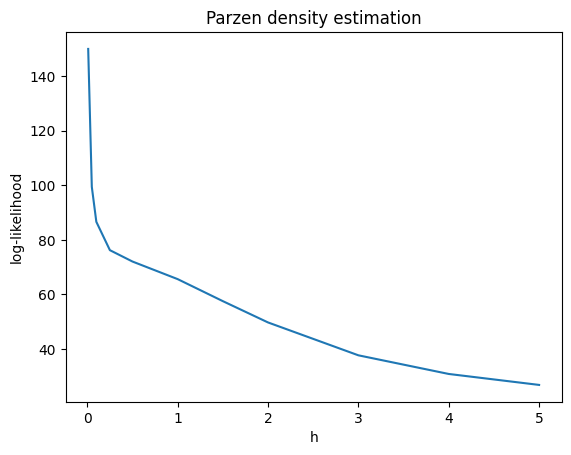

In [34]:
a = pr.gendats([20,20], 1, 8)
a = pr.prdataset(+a)

hs = [0.01,0.05,0.1,0.25,0.5,1,1.5,2,3,4,5] # Array of h’s to try
LL = np.zeros(len(hs))
for i in range(len(hs)):
                                       # For each h...
    w = pr.parzenm(a, hs[i])                  #   estimate Parzen density
    LL[i] = np.sum(np.log(+(a*w)));           #   calculate log-likelihood
plt.plot(hs, LL)
plt.xlabel('h')
plt.ylabel('log-likelihood')
plt.title('Parzen density estimation')
plt.show()

What is the optimal value for h, i.e. the maximal likelihood? Is this also the best density estimate for the dataset?


### Answer
The log-likelihood increases as $h$ decreases. In the plot in figure (a) below, $h$ varies from 0.05 to 5, and the highest log-likelihood is achieved at $h = 0.05$.  This is due to the fact that the log-likelihood is computed on the training set.

### **Exercise 4.2**

Use the same data as in the previous exercise, but now split the data into a training and test set of equal size. Estimate a Parzen density on the training set and compute the Parzen density for the test set. Compute the log-likelihood on both the training and test sets for $ h = [0.1, 0.25, 0.5, 1, 1.5, 2, 3, 4, 5] $. Plot these log-likelihood vs. $ h $ curves

/tmp/ipykernel_15364/1989910264.py:20: RuntimeWarning: divide by zero encountered in log
  Ltst[i] = np.sum(np.log(+(tst * w)))


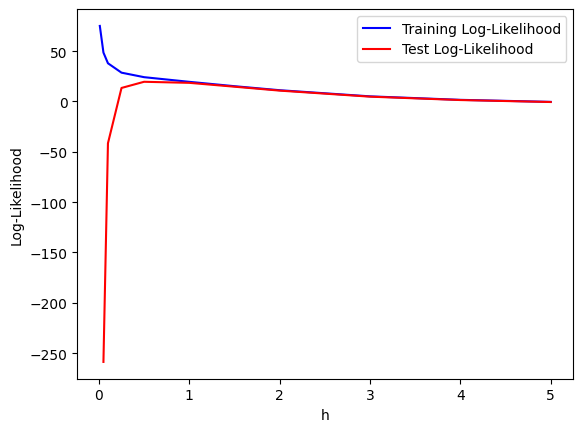

In [37]:
# Split into trn and tst, both 50%
[trn, tst] = pr.gendat(a, 0.5)

# Array of h’s to try
hs = [0.01, 0.05, 0.1, 0.25, 0.5, 1, 1.5, 2, 3, 4, 5]

# Initialize log-likelihood arrays
Ltrn = np.zeros(len(hs))
Ltst = np.zeros(len(hs))

# For each h...
for i in range(len(hs)):
  # Estimate Parzen identity
  w = pr.parzenm(trn, hs[i])

  # Calc trn log-likelihood
  Ltrn[i] = np.sum(np.log(+(trn * w)))

  # Calc tst log-likelihood
  Ltst[i] = np.sum(np.log(+(tst * w)))

# Plot log-likelihood
plt.plot(hs, Ltrn, 'b-', label='Training Log-Likelihood')
plt.plot(hs, Ltst, 'r-', label="Test Log-Likelihood")
plt.xlabel('h')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.show()

What is a good choice for $ h $?

### Answer
The test set curve has a clear maximum at $h = 1$ (and not at the minimal $h$ as in the training set curve. In the training set curve there is a clear
over-training effect.